# EchoMind — Prosódia v4 Advanced FINAL

Este notebook treina uma versão mais forte do módulo de prosódia do EchoMind.

A versão v4 deixa de depender apenas de features acústicas manuais + SVM. Passa a comparar e/ou combinar:

1. **Ramo clássico interpretável**: features acústicas globais e temporais extraídas com `librosa`/`parselmouth` + classificadores calibráveis.
2. **Ramo moderno SSL**: embeddings de fala pré-treinados, por defeito **WavLM**, usados como extrator congelado + classificador leve.
3. **Ramo combinado/ensemble**: combinação de features manuais e embeddings SSL, ou ensemble interno entre os dois ramos.

O objetivo é reduzir o problema observado de a prosódia prever quase sempre a mesma classe, por exemplo `anger`, e produzir uma distribuição acústica mais útil para a fusão multimodal.

Classes finais:

```text
joy, sadness, surprise, fear, anger, disgust, neutral
```

Saída principal do notebook:

```text
prosody_outputs_v4/prosody_final_artifact_v4.joblib
```

Esse artefacto é consumido pelo notebook `EchoMind_multimodal_fusion_v4_FINAL.ipynb`.

In [1]:
# ============================================================
# 1. Instalação de dependências
# ============================================================
# Em Colab ou ambiente novo, descomenta a linha seguinte.
# A primeira execução com WavLM precisa de internet para descarregar o modelo.
# Depois de descarregado, o modelo fica em cache local do Hugging Face.

# !pip install -q numpy pandas matplotlib tqdm joblib scikit-learn imbalanced-learn librosa soundfile praat-parselmouth torch transformers accelerate

print("✅ Célula de instalação pronta.")


✅ Célula de instalação pronta.


In [2]:
# ============================================================
# 2. Imports, configuração global e utilidades
# ============================================================

import os
import re
import json
import math
import time
import random
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import joblib

import librosa
import soundfile as sf

from sklearn.base import clone
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import RandomOverSampler, SMOTE
    IMBLEARN_AVAILABLE = True
except Exception as e:
    print("⚠️ imbalanced-learn indisponível. O notebook continua sem oversampling.", repr(e))
    ImbPipeline = SkPipeline
    RandomOverSampler = None
    SMOTE = None
    IMBLEARN_AVAILABLE = False

try:
    import torch
    from transformers import AutoFeatureExtractor, AutoModel
    TRANSFORMERS_AVAILABLE = True
except Exception as e:
    print("⚠️ torch/transformers indisponível. O ramo WavLM será ignorado.", repr(e))
    torch = None
    AutoFeatureExtractor = None
    AutoModel = None
    TRANSFORMERS_AVAILABLE = False

try:
    import parselmouth
    PARSELMOUTH_AVAILABLE = True
except Exception:
    PARSELMOUTH_AVAILABLE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

EMOTIONS = ["joy", "sadness", "surprise", "fear", "anger", "disgust", "neutral"]
TARGET_SR = 16000
OUTPUT_DIR = Path("prosody_outputs_v4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Liga/desliga o ramo moderno. Se der erro ao descarregar/carregar WavLM, o notebook faz fallback automático.
USE_SSL_EMBEDDINGS = True
SSL_MODEL_NAME = os.environ.get("ECHOMIND_SSL_MODEL", "microsoft/wavlm-base")
# Alternativas úteis: "facebook/wav2vec2-base", "microsoft/wavlm-base-plus"

# Para datasets pequenos, manter chunking evita problemas de memória em áudios longos.
SSL_MAX_SECONDS_PER_CHUNK = 12.0
SSL_CHUNK_OVERLAP_SECONDS = 1.0

print("✅ Configuração carregada")
print("Transformers disponível:", TRANSFORMERS_AVAILABLE)
print("Parselmouth disponível:", PARSELMOUTH_AVAILABLE)
print("Imbalanced-learn disponível:", IMBLEARN_AVAILABLE)
print("SSL_MODEL_NAME:", SSL_MODEL_NAME)


⚠️ imbalanced-learn indisponível. O notebook continua sem oversampling. ModuleNotFoundError("No module named 'imblearn'")
✅ Configuração carregada
Transformers disponível: True
Parselmouth disponível: True
Imbalanced-learn disponível: False
SSL_MODEL_NAME: microsoft/wavlm-base


In [3]:
# ============================================================
# 3. Caminho do dataset
# ============================================================
# Estrutura recomendada:
# dataset/
#   anger/speaker_1/*.wav
#   disgust/speaker_1/*.wav
#   fear/speaker_1/*.wav
#   happiness/speaker_1/*.wav
#   neutral/speaker_1/*.wav
#   sadness/speaker_1/*.wav
#   surprise/speaker_1/*.wav
#
# Também aceita nomes como Anger, Happiness, Joy, Sadness, etc.

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    # Se estiveres no Colab, podes montar o Drive:
    # from google.colab import drive
    # drive.mount('/content/drive')
    DEFAULT_DATASET_ROOT = Path("/content/drive/MyDrive/dataset")
else:
    DEFAULT_DATASET_ROOT = Path("./dataset")

DATASET_ROOT = Path(os.environ.get("DATASET_ROOT", str(DEFAULT_DATASET_ROOT)))
print(f"📁 DATASET_ROOT = {DATASET_ROOT.resolve()}")
if not DATASET_ROOT.exists():
    print("⚠️ Dataset não encontrado. Ajusta DATASET_ROOT antes de correr as células seguintes.")


📁 DATASET_ROOT = /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/prosody/dataset


In [4]:
# ============================================================
# 4. Carregamento robusto do dataset organizado
# ============================================================

FOLDER_TO_LABEL = {
    "anger": "anger", "angry": "anger", "raiva": "anger",
    "disgust": "disgust", "nojo": "disgust",
    "fear": "fear", "medo": "fear",
    "happiness": "joy", "happy": "joy", "joy": "joy", "alegria": "joy",
    "neutral": "neutral", "neutro": "neutral",
    "sadness": "sadness", "sad": "sadness", "tristeza": "sadness",
    "surprise": "surprise", "surprised": "surprise", "surpresa": "surprise",
}
AUDIO_EXTS = {".wav", ".mp3", ".flac", ".ogg", ".m4a", ".aac", ".webm"}


def normalize_name(name: str) -> str:
    return re.sub(r"[^a-zA-Z0-9]+", "", str(name).strip().lower())


def infer_label_from_path(path: Path, root: Path) -> Optional[str]:
    rel_parts = path.relative_to(root).parts
    for part in rel_parts[:-1]:
        key = normalize_name(part)
        if key in FOLDER_TO_LABEL:
            return FOLDER_TO_LABEL[key]
    return None


def infer_speaker_from_path(path: Path, root: Path, label: str) -> str:
    rel_parts = list(path.relative_to(root).parts)
    # tenta encontrar a pasta da emoção; a pasta seguinte é o speaker
    for i, part in enumerate(rel_parts[:-1]):
        if FOLDER_TO_LABEL.get(normalize_name(part)) == label:
            if i + 1 < len(rel_parts) - 1:
                return rel_parts[i + 1]
            return "speaker_unknown"
    # fallback: pasta imediatamente acima do ficheiro
    return path.parent.name if path.parent != root else "speaker_unknown"

records = []
if DATASET_ROOT.exists():
    for file_path in sorted(DATASET_ROOT.rglob("*")):
        if not file_path.is_file() or file_path.suffix.lower() not in AUDIO_EXTS:
            continue
        label = infer_label_from_path(file_path, DATASET_ROOT)
        if label is None:
            continue
        speaker = infer_speaker_from_path(file_path, DATASET_ROOT, label)
        records.append({
            "audio_id": f"aud_{len(records):05d}",
            "path": str(file_path),
            "filename": file_path.name,
            "speaker": str(speaker),
            "true_label": label,
        })

metadata_df = pd.DataFrame(records)
if metadata_df.empty:
    print("⚠️ Nenhum áudio encontrado. Verifica DATASET_ROOT e a organização das pastas.")
else:
    print(f"✅ Áudios encontrados: {len(metadata_df)}")
    print(f"✅ Speakers encontrados: {metadata_df['speaker'].nunique()}")
    display(metadata_df.head())

metadata_df.to_csv(OUTPUT_DIR / "metadata_v4.csv", index=False)


✅ Áudios encontrados: 480
✅ Speakers encontrados: 4


,audio_id,path,filename,speaker,true_label
0,aud_00000,dataset/Anger/DC/DC_a01.wav,DC_a01.wav,DC,anger
1,aud_00001,dataset/Anger/DC/DC_a02.wav,DC_a02.wav,DC,anger
2,aud_00002,dataset/Anger/DC/DC_a03.wav,DC_a03.wav,DC,anger
3,aud_00003,dataset/Anger/DC/DC_a04.wav,DC_a04.wav,DC,anger
4,aud_00004,dataset/Anger/DC/DC_a05.wav,DC_a05.wav,DC,anger


📊 Contagem por emoção:
true_label
joy          60
sadness      60
surprise     60
fear         60
anger        60
disgust      60
neutral     120
Name: count, dtype: int64

📌 Rácio de desequilíbrio max/min: 2.00

📊 Contagem por speaker:
speaker
DC    120
JE    120
JK    120
KL    120
Name: count, dtype: int64


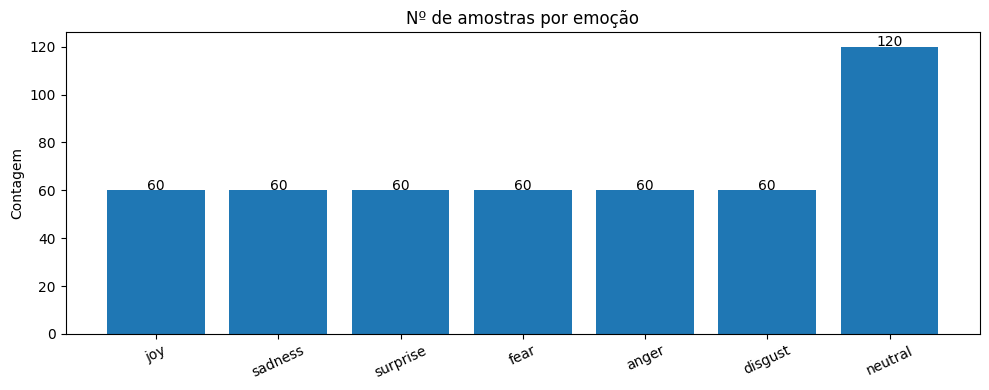

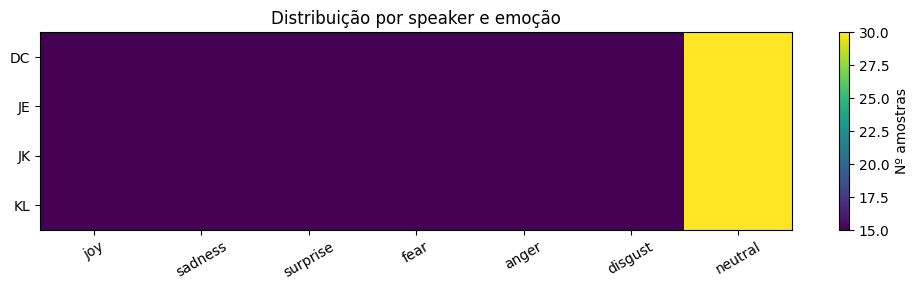

In [5]:
# ============================================================
# 5. Diagnóstico do dataset e desequilíbrio
# ============================================================

if metadata_df.empty:
    raise RuntimeError("metadata_df está vazio. Corrige DATASET_ROOT antes de continuar.")

emo_counts = metadata_df["true_label"].value_counts().reindex(EMOTIONS).fillna(0).astype(int)
speaker_counts = metadata_df["speaker"].value_counts()
pivot = metadata_df.groupby(["speaker", "true_label"]).size().unstack(fill_value=0).reindex(columns=EMOTIONS, fill_value=0)

nonzero = emo_counts[emo_counts > 0]
imbalance_ratio = float(emo_counts.max() / max(1, nonzero.min())) if len(nonzero) else 0.0
print("📊 Contagem por emoção:")
print(emo_counts)
print(f"\n📌 Rácio de desequilíbrio max/min: {imbalance_ratio:.2f}")
print("\n📊 Contagem por speaker:")
print(speaker_counts)

if metadata_df["speaker"].nunique() < 2:
    print("⚠️ Só há um speaker. LOSO-CV não será possível; será usado StratifiedKFold como fallback.")

plt.figure(figsize=(10, 4))
plt.bar(emo_counts.index, emo_counts.values)
plt.title("Nº de amostras por emoção")
plt.ylabel("Contagem")
plt.xticks(rotation=25)
for i, v in enumerate(emo_counts.values):
    plt.text(i, v + 0.2, str(v), ha="center")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dataset_distribution_emotions_v4.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, max(3, 0.4 * len(pivot))))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Nº amostras")
plt.xticks(range(len(EMOTIONS)), EMOTIONS, rotation=30)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Distribuição por speaker e emoção")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dataset_distribution_speaker_emotion_v4.png", dpi=160, bbox_inches="tight")
plt.show()


In [6]:
# ============================================================
# 6. Extração de features acústicas manuais v4
# ============================================================

TRIM_SILENCE = True
TOP_DB = 25
MIN_SECONDS = 0.75
N_SEGMENTS = 4


def load_audio(path: str | Path, target_sr: int = TARGET_SR) -> Tuple[np.ndarray, int]:
    y, sr = librosa.load(str(path), sr=target_sr, mono=True)
    y = np.asarray(y, dtype=np.float32)
    if TRIM_SILENCE and y.size > 0:
        y, _ = librosa.effects.trim(y, top_db=TOP_DB)
    min_len = int(MIN_SECONDS * target_sr)
    if len(y) < min_len:
        y = np.pad(y, (0, min_len - len(y)))
    if np.max(np.abs(y)) > 0:
        y = y / max(1.0, float(np.max(np.abs(y))))
    return y.astype(np.float32), target_sr


def _safe_stats(prefix: str, values: np.ndarray, percentiles: bool = True) -> Dict[str, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    keys = ["mean", "std", "min", "max", "median", "range"]
    if percentiles:
        keys += ["p10", "p25", "p75", "p90", "iqr"]
    if values.size == 0:
        return {f"{prefix}_{k}": np.nan for k in keys}
    out = {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_min": float(np.min(values)),
        f"{prefix}_max": float(np.max(values)),
        f"{prefix}_median": float(np.median(values)),
        f"{prefix}_range": float(np.max(values) - np.min(values)),
    }
    if percentiles:
        p10, p25, p75, p90 = np.percentile(values, [10, 25, 75, 90])
        out.update({
            f"{prefix}_p10": float(p10),
            f"{prefix}_p25": float(p25),
            f"{prefix}_p75": float(p75),
            f"{prefix}_p90": float(p90),
            f"{prefix}_iqr": float(p75 - p25),
        })
    return out


def _pitch_features_librosa(y: np.ndarray, sr: int, prefix: str) -> Dict[str, float]:
    feats = {}
    try:
        f0, voiced_flag, voiced_prob = librosa.pyin(
            y,
            fmin=librosa.note_to_hz("C2"),
            fmax=librosa.note_to_hz("C7"),
            sr=sr,
            frame_length=2048,
            hop_length=256,
        )
        voiced = f0[voiced_flag & np.isfinite(f0)] if voiced_flag is not None else np.array([])
        feats.update(_safe_stats(f"{prefix}_f0", voiced))
        feats[f"{prefix}_voiced_ratio"] = float(np.mean(voiced_flag)) if voiced_flag is not None and len(voiced_flag) else np.nan
        if voiced_prob is not None:
            feats.update(_safe_stats(f"{prefix}_voiced_prob", voiced_prob, percentiles=False))
    except Exception:
        feats.update(_safe_stats(f"{prefix}_f0", np.array([])))
        feats[f"{prefix}_voiced_ratio"] = np.nan
    return feats


def _pitch_features_parselmouth(y: np.ndarray, sr: int, prefix: str) -> Dict[str, float]:
    feats = {}
    if not PARSELMOUTH_AVAILABLE:
        return feats
    try:
        snd = parselmouth.Sound(y, sampling_frequency=sr)
        pitch = snd.to_pitch(time_step=0.01, pitch_floor=50, pitch_ceiling=500)
        f0 = pitch.selected_array["frequency"]
        f0 = f0[f0 > 0]
        feats.update(_safe_stats(f"{prefix}_praat_f0", f0))
        point_process = parselmouth.praat.call(snd, "To PointProcess (periodic, cc)", 50, 500)
        local_jitter = parselmouth.praat.call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        local_shimmer = parselmouth.praat.call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        feats[f"{prefix}_jitter_local"] = float(local_jitter) if np.isfinite(local_jitter) else np.nan
        feats[f"{prefix}_shimmer_local"] = float(local_shimmer) if np.isfinite(local_shimmer) else np.nan
    except Exception:
        feats[f"{prefix}_jitter_local"] = np.nan
        feats[f"{prefix}_shimmer_local"] = np.nan
    return feats


def extract_manual_features_from_signal(y: np.ndarray, sr: int, prefix: str = "global") -> Dict[str, float]:
    feats: Dict[str, float] = {}
    duration = len(y) / sr if sr else 0.0
    feats[f"{prefix}_duration"] = float(duration)

    rms = librosa.feature.rms(y=y, frame_length=1024, hop_length=256)[0]
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=1024, hop_length=256)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=256)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=256)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=256)[0]
    flatness = librosa.feature.spectral_flatness(y=y, hop_length=256)[0]
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=256)

    feats.update(_safe_stats(f"{prefix}_rms", rms))
    feats.update(_safe_stats(f"{prefix}_zcr", zcr))
    feats.update(_safe_stats(f"{prefix}_centroid", centroid))
    feats.update(_safe_stats(f"{prefix}_bandwidth", bandwidth))
    feats.update(_safe_stats(f"{prefix}_rolloff", rolloff))
    feats.update(_safe_stats(f"{prefix}_flatness", flatness))
    feats.update(_safe_stats(f"{prefix}_onset", onset_env))

    # Pausas aproximadas: frames com energia muito baixa.
    if len(rms):
        thr = np.percentile(rms, 25) * 0.75
        low_energy = rms < thr
        feats[f"{prefix}_low_energy_ratio"] = float(np.mean(low_energy))
    else:
        feats[f"{prefix}_low_energy_ratio"] = np.nan

    try:
        tempo = librosa.feature.tempo(onset_envelope=onset_env, sr=sr, hop_length=256)
        feats[f"{prefix}_tempo"] = float(np.ravel(tempo)[0]) if len(np.ravel(tempo)) else np.nan
    except Exception:
        feats[f"{prefix}_tempo"] = np.nan

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, hop_length=256)
    for i in range(mfcc.shape[0]):
        feats.update(_safe_stats(f"{prefix}_mfcc{i+1}", mfcc[i], percentiles=False))

    try:
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=256)
        for i in range(chroma.shape[0]):
            feats.update(_safe_stats(f"{prefix}_chroma{i+1}", chroma[i], percentiles=False))
    except Exception:
        pass

    feats.update(_pitch_features_librosa(y, sr, prefix))
    if prefix == "global":
        feats.update(_pitch_features_parselmouth(y, sr, prefix))

    return feats


def extract_manual_features_from_file(path: str | Path, audio_id: Optional[str] = None) -> Dict[str, float]:
    y, sr = load_audio(path, TARGET_SR)
    feats: Dict[str, float] = {}
    feats["audio_id"] = audio_id if audio_id is not None else Path(path).stem
    feats["duration_sec"] = float(len(y) / sr)

    feats.update(extract_manual_features_from_signal(y, sr, prefix="global"))

    seg_len = max(1, len(y) // N_SEGMENTS)
    segment_summaries = []
    for i in range(N_SEGMENTS):
        start = i * seg_len
        end = len(y) if i == N_SEGMENTS - 1 else min(len(y), (i + 1) * seg_len)
        seg = y[start:end]
        if len(seg) < int(0.25 * sr):
            seg = np.pad(seg, (0, int(0.25 * sr) - len(seg)))
        seg_prefix = f"seg{i+1}"
        seg_feats = extract_manual_features_from_signal(seg, sr, prefix=seg_prefix)
        feats.update(seg_feats)
        segment_summaries.append(seg_feats)

    # Tendências simples entre início e fim.
    for base in ["rms_mean", "f0_mean", "zcr_mean", "centroid_mean", "onset_mean"]:
        first_key = f"seg1_{base}"
        last_key = f"seg{N_SEGMENTS}_{base}"
        feats[f"trend_{base}"] = float(feats.get(last_key, np.nan) - feats.get(first_key, np.nan))

    return feats

print("✅ Funções de features manuais prontas.")


✅ Funções de features manuais prontas.


In [7]:
# ============================================================
# 7. Extração de features manuais para todo o dataset, com cache
# ============================================================

FORCE_REEXTRACT_MANUAL = False
MANUAL_FEATURE_CACHE = OUTPUT_DIR / "manual_features_v4.csv"
FAILED_MANUAL_CACHE = OUTPUT_DIR / "failed_manual_features_v4.csv"

if MANUAL_FEATURE_CACHE.exists() and not FORCE_REEXTRACT_MANUAL:
    print(f"📦 A carregar features manuais em cache: {MANUAL_FEATURE_CACHE}")
    manual_features_df = pd.read_csv(MANUAL_FEATURE_CACHE)
    failed_manual_df = pd.read_csv(FAILED_MANUAL_CACHE) if FAILED_MANUAL_CACHE.exists() else pd.DataFrame()
else:
    rows, failed = [], []
    for _, row in tqdm(metadata_df.iterrows(), total=len(metadata_df), desc="Features manuais v4"):
        try:
            feats = extract_manual_features_from_file(row["path"], row["audio_id"])
            rows.append(feats)
        except Exception as e:
            failed.append({"audio_id": row["audio_id"], "path": row["path"], "error": repr(e)})
    manual_features_df = pd.DataFrame(rows)
    failed_manual_df = pd.DataFrame(failed)
    manual_features_df.to_csv(MANUAL_FEATURE_CACHE, index=False)
    if not failed_manual_df.empty:
        failed_manual_df.to_csv(FAILED_MANUAL_CACHE, index=False)

if not failed_manual_df.empty:
    print(f"⚠️ Falharam {len(failed_manual_df)} ficheiros na extração manual.")
    display(failed_manual_df.head())

ml_manual_df = metadata_df.merge(manual_features_df, on="audio_id", how="inner")
print("✅ ml_manual_df:", ml_manual_df.shape)
display(ml_manual_df.head())


📦 A carregar features manuais em cache: prosody_outputs_v4/manual_features_v4.csv
✅ ml_manual_df: (480, 1264)


,audio_id,path,filename,speaker,true_label,duration_sec,global_duration,global_rms_mean,global_rms_std,global_rms_min,...,seg4_voiced_prob_std,seg4_voiced_prob_min,seg4_voiced_prob_max,seg4_voiced_prob_median,seg4_voiced_prob_range,trend_rms_mean,trend_f0_mean,trend_zcr_mean,trend_centroid_mean,trend_onset_mean
0,aud_00000,dataset/Anger/DC/DC_a01.wav,DC_a01.wav,DC,anger,3.647813,3.647813,0.130469,0.098766,0.034437,...,0.122791,0.000000,0.686083,0.010000,0.686083,0.020628,17.159668,0.000998,-144.501686,-0.900270
1,aud_00001,dataset/Anger/DC/DC_a02.wav,DC_a02.wav,DC,anger,3.438188,3.438188,0.126195,0.095768,0.028065,...,0.017487,0.000000,0.108580,0.000000,0.108580,-0.056999,-57.365094,-0.001302,475.394449,-0.651715
2,aud_00002,dataset/Anger/DC/DC_a03.wav,DC_a03.wav,DC,anger,2.075500,2.075500,0.146178,0.132621,0.027753,...,0.004368,0.000000,0.013980,0.000000,0.013980,0.000595,NaN,0.001095,-29.878560,0.129148
3,aud_00003,dataset/Anger/DC/DC_a04.wav,DC_a04.wav,DC,anger,2.208000,2.208000,0.175795,0.170639,0.011496,...,0.166955,0.010000,0.615950,0.010824,0.605950,-0.031244,-91.854819,0.080971,718.753290,0.622155
4,aud_00004,dataset/Anger/DC/DC_a05.wav,DC_a05.wav,DC,anger,1.888000,1.888000,0.223377,0.154155,0.010061,...,0.304365,0.010038,0.891144,0.240754,0.881107,-0.039840,-62.121693,-0.054590,-874.016903,-0.833162


In [8]:
# ============================================================
# 8. Extração de embeddings SSL/WavLM, com fallback seguro
# ============================================================

_ssl_feature_extractor = None
_ssl_model = None
_ssl_device = None
_ssl_loaded_model_name = None


def get_ssl_device() -> str:
    if not TRANSFORMERS_AVAILABLE or torch is None:
        return "none"
    return "cuda" if torch.cuda.is_available() else "cpu"


def load_ssl_model(model_name: str = SSL_MODEL_NAME):
    global _ssl_feature_extractor, _ssl_model, _ssl_device, _ssl_loaded_model_name
    if not TRANSFORMERS_AVAILABLE:
        raise RuntimeError("torch/transformers não estão disponíveis.")
    if _ssl_model is not None and _ssl_loaded_model_name == model_name:
        return _ssl_feature_extractor, _ssl_model, _ssl_device
    _ssl_device = get_ssl_device()
    print(f"🔊 A carregar modelo SSL: {model_name} em {_ssl_device}")
    _ssl_feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
    _ssl_model = AutoModel.from_pretrained(model_name)
    _ssl_model.to(_ssl_device)
    _ssl_model.eval()
    _ssl_loaded_model_name = model_name
    return _ssl_feature_extractor, _ssl_model, _ssl_device


def _iter_audio_chunks(y: np.ndarray, sr: int, max_seconds: float, overlap_seconds: float):
    max_len = int(max_seconds * sr)
    overlap = int(overlap_seconds * sr)
    if len(y) <= max_len:
        yield y
        return
    step = max(1, max_len - overlap)
    for start in range(0, len(y), step):
        chunk = y[start:start + max_len]
        if len(chunk) < int(0.5 * sr):
            break
        yield chunk
        if start + max_len >= len(y):
            break


def extract_ssl_embedding_from_signal(y: np.ndarray, sr: int = TARGET_SR, model_name: str = SSL_MODEL_NAME) -> np.ndarray:
    feature_extractor, model, device = load_ssl_model(model_name)
    chunk_embeddings = []
    for chunk in _iter_audio_chunks(y, sr, SSL_MAX_SECONDS_PER_CHUNK, SSL_CHUNK_OVERLAP_SECONDS):
        inputs = feature_extractor(
            chunk,
            sampling_rate=sr,
            return_tensors="pt",
            padding=True,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            hidden = outputs.last_hidden_state.squeeze(0)
            mean_pool = hidden.mean(dim=0).detach().cpu().numpy()
            std_pool = hidden.std(dim=0).detach().cpu().numpy()
        chunk_embeddings.append(np.concatenate([mean_pool, std_pool]))
    if not chunk_embeddings:
        raise RuntimeError("Não foi possível extrair embeddings SSL: áudio vazio.")
    emb = np.vstack(chunk_embeddings)
    # Pooling sobre chunks: média e desvio do embedding por chunk.
    if emb.shape[0] == 1:
        return emb[0].astype(np.float32)
    return np.concatenate([emb.mean(axis=0), emb.std(axis=0)]).astype(np.float32)


def extract_ssl_embedding_from_file(path: str | Path, model_name: str = SSL_MODEL_NAME) -> np.ndarray:
    y, sr = load_audio(path, TARGET_SR)
    return extract_ssl_embedding_from_signal(y, sr, model_name)

FORCE_REEXTRACT_SSL = False
SSL_FEATURE_CACHE = OUTPUT_DIR / f"ssl_embeddings_v4_{normalize_name(SSL_MODEL_NAME)}.csv"
SSL_META_PATH = OUTPUT_DIR / f"ssl_embeddings_v4_{normalize_name(SSL_MODEL_NAME)}_meta.json"

ssl_available = False
ssl_features_df = pd.DataFrame()

if USE_SSL_EMBEDDINGS:
    if SSL_FEATURE_CACHE.exists() and not FORCE_REEXTRACT_SSL:
        print(f"📦 A carregar embeddings SSL em cache: {SSL_FEATURE_CACHE}")
        ssl_features_df = pd.read_csv(SSL_FEATURE_CACHE)
        ssl_available = not ssl_features_df.empty
    else:
        try:
            # Testa carregamento antes de começar o loop.
            load_ssl_model(SSL_MODEL_NAME)
            rows = []
            for _, row in tqdm(metadata_df.iterrows(), total=len(metadata_df), desc=f"Embeddings SSL: {SSL_MODEL_NAME}"):
                try:
                    emb = extract_ssl_embedding_from_file(row["path"], SSL_MODEL_NAME)
                    emb_row = {"audio_id": row["audio_id"]}
                    emb_row.update({f"ssl_{i:04d}": float(v) for i, v in enumerate(emb)})
                    rows.append(emb_row)
                except Exception as e:
                    print(f"⚠️ Falha SSL em {row['filename']}: {repr(e)}")
            ssl_features_df = pd.DataFrame(rows)
            if not ssl_features_df.empty:
                ssl_features_df.to_csv(SSL_FEATURE_CACHE, index=False)
                SSL_META_PATH.write_text(json.dumps({"model_name": SSL_MODEL_NAME, "n_embeddings": ssl_features_df.shape[1]-1}, indent=2), encoding="utf-8")
                ssl_available = True
        except Exception as e:
            print("⚠️ Ramo SSL indisponível. O notebook continua com features manuais.")
            print("Erro:", repr(e))
            ssl_available = False
else:
    print("ℹ️ USE_SSL_EMBEDDINGS=False. A ignorar ramo WavLM/wav2vec2.")

if ssl_available:
    ml_ssl_df = metadata_df.merge(ssl_features_df, on="audio_id", how="inner")
    print("✅ ml_ssl_df:", ml_ssl_df.shape)
    display(ml_ssl_df.head())
else:
    ml_ssl_df = pd.DataFrame()
    print("⚠️ Sem embeddings SSL disponíveis.")


📦 A carregar embeddings SSL em cache: prosody_outputs_v4/ssl_embeddings_v4_microsoftwavlmbase.csv
✅ ml_ssl_df: (480, 1541)


,audio_id,path,filename,speaker,true_label,ssl_0000,ssl_0001,ssl_0002,ssl_0003,ssl_0004,...,ssl_1526,ssl_1527,ssl_1528,ssl_1529,ssl_1530,ssl_1531,ssl_1532,ssl_1533,ssl_1534,ssl_1535
0,aud_00000,dataset/Anger/DC/DC_a01.wav,DC_a01.wav,DC,anger,-0.013947,-0.042519,-0.150060,-0.024909,0.058659,...,0.223707,0.256367,0.217578,0.557753,0.281904,0.248837,0.181749,0.549262,0.307009,0.247770
1,aud_00001,dataset/Anger/DC/DC_a02.wav,DC_a02.wav,DC,anger,-0.006259,0.021171,-0.169805,-0.022021,0.041124,...,0.223867,0.204874,0.202717,0.504383,0.259247,0.259828,0.216578,0.557544,0.283804,0.269309
2,aud_00002,dataset/Anger/DC/DC_a03.wav,DC_a03.wav,DC,anger,-0.131346,0.014301,-0.163318,0.010923,0.006577,...,0.214143,0.169159,0.216473,0.558300,0.328884,0.296500,0.149204,0.541641,0.259406,0.311143
3,aud_00003,dataset/Anger/DC/DC_a04.wav,DC_a04.wav,DC,anger,-0.032070,-0.079525,-0.170682,-0.000117,0.088285,...,0.245639,0.212372,0.203161,0.457145,0.291684,0.236100,0.207174,0.511316,0.314534,0.265502
4,aud_00004,dataset/Anger/DC/DC_a05.wav,DC_a05.wav,DC,anger,0.000707,-0.065876,-0.050127,-0.028377,0.041851,...,0.178600,0.226087,0.206781,0.574251,0.310711,0.296943,0.208038,0.472776,0.324445,0.290116


In [9]:
# ============================================================
# 9. Preparação dos dados para ML
# ============================================================

NON_FEATURE_COLS = {"audio_id", "path", "filename", "speaker", "true_label"}

manual_feature_cols = [
    c for c in ml_manual_df.columns
    if c not in NON_FEATURE_COLS and pd.api.types.is_numeric_dtype(ml_manual_df[c])
]
X_manual = ml_manual_df[manual_feature_cols].copy()
y = ml_manual_df["true_label"].copy().reset_index(drop=True)
groups = ml_manual_df["speaker"].copy().reset_index(drop=True)
X_manual = X_manual.reset_index(drop=True)

valid_mask = y.isin(EMOTIONS)
X_manual = X_manual.loc[valid_mask].reset_index(drop=True)
y = y.loc[valid_mask].reset_index(drop=True)
groups = groups.loc[valid_mask].reset_index(drop=True)

ssl_feature_cols: List[str] = []
X_ssl = pd.DataFrame()
X_combined = pd.DataFrame()

if ssl_available and not ml_ssl_df.empty:
    # Garante alinhamento pelos audio_id finais usados no ramo manual.
    base_ids = ml_manual_df.loc[valid_mask, "audio_id"].reset_index(drop=True)
    aligned_ssl = pd.DataFrame({"audio_id": base_ids}).merge(ssl_features_df, on="audio_id", how="left")
    ssl_feature_cols = [c for c in aligned_ssl.columns if c.startswith("ssl_")]
    X_ssl = aligned_ssl[ssl_feature_cols].copy()
    X_combined = pd.concat([X_manual.reset_index(drop=True), X_ssl.reset_index(drop=True)], axis=1)

class_counts = y.value_counts().reindex(EMOTIONS).fillna(0).astype(int)
class_priors = (class_counts / max(1, class_counts.sum())).replace(0, 1e-9).to_dict()

print(f"✅ X_manual: {X_manual.shape}")
print(f"✅ X_ssl: {X_ssl.shape if not X_ssl.empty else 'indisponível'}")
print(f"✅ X_combined: {X_combined.shape if not X_combined.empty else 'indisponível'}")
print(f"✅ y: {y.shape}")
print(f"✅ grupos/speakers: {sorted(groups.unique())}")
print("\n📊 Contagem final por classe:")
print(class_counts)

if len(class_counts[class_counts > 0]) < len(EMOTIONS):
    print("⚠️ Nem todas as 7 emoções têm exemplos. O classificador só aprende as classes presentes no treino.")

(OUTPUT_DIR / "manual_feature_columns_v4.json").write_text(json.dumps(manual_feature_cols, indent=2), encoding="utf-8")
(OUTPUT_DIR / "ssl_feature_columns_v4.json").write_text(json.dumps(ssl_feature_cols, indent=2), encoding="utf-8")
(OUTPUT_DIR / "class_priors_v4.json").write_text(json.dumps(class_priors, indent=2), encoding="utf-8")


✅ X_manual: (480, 1259)
✅ X_ssl: (480, 1536)
✅ X_combined: (480, 2795)
✅ y: (480,)
✅ grupos/speakers: ['DC', 'JE', 'JK', 'KL']

📊 Contagem final por classe:
true_label
joy          60
sadness      60
surprise     60
fear         60
anger        60
disgust      60
neutral     120
Name: count, dtype: int64


133

In [10]:
# ============================================================
# 10. Construção de pipelines candidatos
# ============================================================


def make_oversampler(y_train: pd.Series):
    if not IMBLEARN_AVAILABLE:
        return None
    counts = pd.Series(y_train).value_counts()
    if counts.min() < 2:
        return RandomOverSampler(random_state=SEED)
    # SMOTE só é seguro se houver vizinhos suficientes por classe.
    k = int(min(3, counts.min() - 1))
    if k >= 1:
        return SMOTE(random_state=SEED, k_neighbors=k)
    return RandomOverSampler(random_state=SEED)


def build_pipeline(model: Any, use_select_k: Optional[int] = None, use_oversampling: bool = False, y_train: Optional[pd.Series] = None):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
    ]
    if use_select_k is not None and use_select_k > 0:
        steps.append(("select", SelectKBest(score_func=f_classif, k=use_select_k)))
    if use_oversampling and y_train is not None:
        sampler = make_oversampler(y_train)
        if sampler is not None:
            steps.append(("sampler", sampler))
            return ImbPipeline(steps + [("clf", model)])
    return SkPipeline(steps + [("clf", model)])


def get_candidate_specs(feature_source: str, n_features: int, y_train: Optional[pd.Series] = None) -> Dict[str, Any]:
    k = min(max(20, n_features // 2), n_features) if n_features > 30 else None
    specs = {}

    if feature_source in {"manual", "combined"}:
        specs[f"{feature_source}_svm_rbf_balanced"] = lambda yt: build_pipeline(
            SVC(kernel="rbf", C=5.0, gamma="scale", class_weight="balanced", probability=True, random_state=SEED),
            use_select_k=k,
            use_oversampling=True,
            y_train=yt,
        )
        specs[f"{feature_source}_logreg_balanced"] = lambda yt: build_pipeline(
            LogisticRegression(max_iter=4000, class_weight="balanced", C=0.7, solver="lbfgs", multi_class="auto", random_state=SEED),
            use_select_k=k,
            use_oversampling=True,
            y_train=yt,
        )
        specs[f"{feature_source}_extra_trees"] = lambda yt: build_pipeline(
            ExtraTreesClassifier(n_estimators=400, class_weight="balanced", min_samples_leaf=2, random_state=SEED, n_jobs=-1),
            use_select_k=None,
            use_oversampling=False,
            y_train=yt,
        )
    else:
        specs[f"{feature_source}_logreg_ssl"] = lambda yt: build_pipeline(
            LogisticRegression(max_iter=5000, class_weight="balanced", C=0.4, solver="lbfgs", multi_class="auto", random_state=SEED),
            use_select_k=None,
            use_oversampling=False,
            y_train=yt,
        )
        specs[f"{feature_source}_svm_linear_ssl"] = lambda yt: build_pipeline(
            SVC(kernel="linear", C=0.5, class_weight="balanced", probability=True, random_state=SEED),
            use_select_k=None,
            use_oversampling=False,
            y_train=yt,
        )
        specs[f"{feature_source}_svm_rbf_ssl"] = lambda yt: build_pipeline(
            SVC(kernel="rbf", C=2.0, gamma="scale", class_weight="balanced", probability=True, random_state=SEED),
            use_select_k=None,
            use_oversampling=False,
            y_train=yt,
        )

    return specs

print("✅ Geradores de pipelines prontos.")


✅ Geradores de pipelines prontos.


In [11]:
# ============================================================
# 11. Avaliação LOSO-CV / fallback StratifiedKFold
# ============================================================


def normalize_vector(p: np.ndarray) -> np.ndarray:
    p = np.asarray(p, dtype=float)
    p = np.nan_to_num(p, nan=0.0, posinf=0.0, neginf=0.0)
    p = np.clip(p, 0.0, None)
    s = float(p.sum())
    if s <= 0:
        return np.ones_like(p, dtype=float) / len(p)
    return p / s


def aligned_predict_proba(model: Any, X_part: pd.DataFrame, emotions: List[str] = EMOTIONS) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        raw = model.predict_proba(X_part)
        classes = list(model.classes_) if hasattr(model, "classes_") else list(getattr(model.named_steps.get("clf"), "classes_", []))
    else:
        decision = model.decision_function(X_part)
        if decision.ndim == 1:
            decision = np.vstack([-decision, decision]).T
        e = np.exp(decision - decision.max(axis=1, keepdims=True))
        raw = e / e.sum(axis=1, keepdims=True)
        classes = list(model.classes_) if hasattr(model, "classes_") else list(getattr(model.named_steps.get("clf"), "classes_", []))

    out = np.zeros((len(X_part), len(emotions)), dtype=float)
    for j, cls in enumerate(classes):
        if cls in emotions:
            out[:, emotions.index(cls)] = raw[:, j]
    out = np.vstack([normalize_vector(row) for row in out])
    return out


def make_cv_splits(y: pd.Series, groups: pd.Series):
    if groups.nunique() >= 2:
        logo = LeaveOneGroupOut()
        return list(logo.split(np.zeros(len(y)), y, groups)), "LOSO"
    n_splits = min(5, int(y.value_counts().min()))
    if n_splits < 2:
        raise RuntimeError("Dados insuficientes para validação: é preciso pelo menos 2 exemplos por classe ou 2 speakers.")
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    return list(skf.split(np.zeros(len(y)), y)), f"StratifiedKFold-{n_splits}"


def evaluate_candidate(name: str, builder, X: pd.DataFrame, y: pd.Series, groups: pd.Series, feature_source: str) -> Tuple[Dict[str, Any], np.ndarray, List[str]]:
    splits, cv_name = make_cv_splits(y, groups)
    oof_probs = np.zeros((len(y), len(EMOTIONS)), dtype=float)
    oof_pred = np.array([None] * len(y), dtype=object)
    fold_notes = []

    for fold, (tr, te) in enumerate(splits, start=1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]
        if y_tr.nunique() < 2:
            fold_notes.append(f"fold {fold}: treino com <2 classes; ignorado")
            continue
        try:
            model = builder(y_tr)
            model.fit(X_tr, y_tr)
            probs = aligned_predict_proba(model, X_te)
            preds = np.array([EMOTIONS[i] for i in probs.argmax(axis=1)])
            oof_probs[te] = probs
            oof_pred[te] = preds
        except Exception as e:
            fold_notes.append(f"fold {fold}: erro {repr(e)}")
            # fallback: prior do treino
            counts = y_tr.value_counts().reindex(EMOTIONS).fillna(0).astype(float).values
            probs = normalize_vector(counts)
            oof_probs[te] = probs
            oof_pred[te] = np.array([EMOTIONS[int(np.argmax(probs))]] * len(te), dtype=object)

    mask = pd.notna(pd.Series(oof_pred))
    y_eval = y[mask].reset_index(drop=True)
    pred_eval = pd.Series(oof_pred[mask]).reset_index(drop=True)
    probs_eval = oof_probs[mask]

    f1_macro = f1_score(y_eval, pred_eval, labels=EMOTIONS, average="macro", zero_division=0)
    f1_weighted = f1_score(y_eval, pred_eval, labels=EMOTIONS, average="weighted", zero_division=0)
    acc = accuracy_score(y_eval, pred_eval)
    bal_acc = balanced_accuracy_score(y_eval, pred_eval)

    pred_counts = pred_eval.value_counts().reindex(EMOTIONS).fillna(0).astype(int)
    pred_diversity = int((pred_counts > 0).sum())
    max_pred_share = float(pred_counts.max() / max(1, pred_counts.sum()))
    collapse_penalty = max(0.0, max_pred_share - 0.55) * 0.35 + max(0.0, 3 - pred_diversity) * 0.03
    selection_score = float(f1_macro + 0.08 * bal_acc + 0.03 * (pred_diversity / len(EMOTIONS)) - collapse_penalty)

    row = {
        "name": name,
        "feature_source": feature_source,
        "cv": cv_name,
        "n_samples_eval": int(len(y_eval)),
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "f1_macro": float(f1_macro),
        "f1_weighted": float(f1_weighted),
        "prediction_diversity": pred_diversity,
        "max_prediction_share": max_pred_share,
        "collapse_penalty": float(collapse_penalty),
        "selection_score": selection_score,
        "notes": " | ".join(fold_notes[:5]),
    }
    return row, oof_probs, list(oof_pred)

print("✅ Funções de avaliação prontas.")


✅ Funções de avaliação prontas.


In [12]:
# ============================================================
# 12. Correr benchmark dos ramos manual, SSL e combinado
# ============================================================

candidate_results: List[Dict[str, Any]] = []
oof_prob_store: Dict[str, np.ndarray] = {}
oof_pred_store: Dict[str, List[str]] = {}
builders_store: Dict[str, Any] = {}
feature_source_store: Dict[str, str] = {}

# Ramo manual.
manual_specs = get_candidate_specs("manual", X_manual.shape[1])
for name, builder in tqdm(manual_specs.items(), desc="Benchmark manual"):
    row, probs, preds = evaluate_candidate(name, builder, X_manual, y, groups, "manual")
    candidate_results.append(row)
    oof_prob_store[name] = probs
    oof_pred_store[name] = preds
    builders_store[name] = builder
    feature_source_store[name] = "manual"

# Ramo SSL.
if ssl_available and not X_ssl.empty:
    ssl_specs = get_candidate_specs("ssl", X_ssl.shape[1])
    for name, builder in tqdm(ssl_specs.items(), desc="Benchmark SSL"):
        row, probs, preds = evaluate_candidate(name, builder, X_ssl, y, groups, "ssl")
        candidate_results.append(row)
        oof_prob_store[name] = probs
        oof_pred_store[name] = preds
        builders_store[name] = builder
        feature_source_store[name] = "ssl"

# Ramo combinado: features manuais + SSL.
if ssl_available and not X_combined.empty:
    combined_specs = get_candidate_specs("combined", X_combined.shape[1])
    for name, builder in tqdm(combined_specs.items(), desc="Benchmark combinado"):
        row, probs, preds = evaluate_candidate(name, builder, X_combined, y, groups, "combined")
        candidate_results.append(row)
        oof_prob_store[name] = probs
        oof_pred_store[name] = preds
        builders_store[name] = builder
        feature_source_store[name] = "combined"

results_df = pd.DataFrame(candidate_results).sort_values("selection_score", ascending=False).reset_index(drop=True)
results_df.to_csv(OUTPUT_DIR / "prosody_model_benchmark_v4.csv", index=False)
print("✅ Benchmark concluído")
display(results_df)


Benchmark combinado: 100%|██████████| 3/3 [00:15<00:00,  5.20s/it]

✅ Benchmark concluído


,name,feature_source,cv,n_samples_eval,accuracy,balanced_accuracy,f1_macro,f1_weighted,prediction_diversity,max_prediction_share,collapse_penalty,selection_score,notes
0,ssl_logreg_ssl,ssl,LOSO,480,0.783333,0.760714,0.766659,0.777430,7,0.302083,0.0,0.857516,
1,ssl_svm_rbf_ssl,ssl,LOSO,480,0.775000,0.764286,0.762622,0.775345,7,0.241667,0.0,0.853765,
2,ssl_svm_linear_ssl,ssl,LOSO,480,0.770833,0.750000,0.750932,0.767066,7,0.270833,0.0,0.840932,
3,combined_logreg_balanced,combined,LOSO,480,0.695833,0.663095,0.672053,0.685758,7,0.341667,0.0,0.755101,
4,combined_svm_rbf_balanced,combined,LOSO,480,0.672917,0.655952,0.660445,0.675626,7,0.256250,0.0,0.742921,
5,combined_extra_trees,combined,LOSO,480,0.543750,0.498810,0.519228,0.531420,7,0.445833,0.0,0.589133,
6,manual_svm_rbf_balanced,manual,LOSO,480,0.462500,0.439286,0.445727,0.459714,7,0.310417,0.0,0.510870,
7,manual_extra_trees,manual,LOSO,480,0.437500,0.389286,0.398496,0.421113,7,0.418750,0.0,0.459638,
8,manual_logreg_balanced,manual,LOSO,480,0.420833,0.384524,0.388048,0.407495,7,0.370833,0.0,0.448810,


In [13]:
# ============================================================
# 13. Testar ensemble interno entre melhor manual e melhor SSL
# ============================================================


def entropy_confidence_from_probs(p: np.ndarray) -> float:
    p = normalize_vector(p)
    ent = -np.sum(np.clip(p, 1e-12, 1.0) * np.log(np.clip(p, 1e-12, 1.0)))
    return float(1.0 - ent / np.log(len(p)))


def margin_confidence_from_probs(p: np.ndarray) -> float:
    p = normalize_vector(p)
    top = np.sort(p)[::-1]
    return float(top[0] - top[1]) if len(top) >= 2 else 0.0


def combined_confidence_from_probs(p: np.ndarray) -> float:
    return float(np.clip(0.65 * entropy_confidence_from_probs(p) + 0.35 * margin_confidence_from_probs(p), 0.0, 1.0))


def adaptive_two_branch_ensemble_probs(p_a: np.ndarray, p_b: np.ndarray, rel_a: float, rel_b: float) -> Tuple[np.ndarray, List[Dict[str, float]]]:
    fused = []
    metas = []
    for pa, pb in zip(p_a, p_b):
        ca = combined_confidence_from_probs(pa)
        cb = combined_confidence_from_probs(pb)
        sa = max(1e-4, rel_a) * (0.50 + 0.50 * ca)
        sb = max(1e-4, rel_b) * (0.50 + 0.50 * cb)
        wa = sa / (sa + sb)
        wb = 1.0 - wa
        fp = normalize_vector(wa * normalize_vector(pa) + wb * normalize_vector(pb))
        fused.append(fp)
        metas.append({"w_a": float(wa), "w_b": float(wb), "conf_a": ca, "conf_b": cb})
    return np.vstack(fused), metas


def evaluate_oof_probs(name: str, probs: np.ndarray, y: pd.Series, feature_source: str) -> Dict[str, Any]:
    preds = np.array([EMOTIONS[i] for i in probs.argmax(axis=1)])
    f1_macro = f1_score(y, preds, labels=EMOTIONS, average="macro", zero_division=0)
    f1_weighted = f1_score(y, preds, labels=EMOTIONS, average="weighted", zero_division=0)
    acc = accuracy_score(y, preds)
    bal_acc = balanced_accuracy_score(y, preds)
    pred_counts = pd.Series(preds).value_counts().reindex(EMOTIONS).fillna(0).astype(int)
    pred_diversity = int((pred_counts > 0).sum())
    max_pred_share = float(pred_counts.max() / max(1, pred_counts.sum()))
    collapse_penalty = max(0.0, max_pred_share - 0.55) * 0.35 + max(0.0, 3 - pred_diversity) * 0.03
    selection_score = float(f1_macro + 0.08 * bal_acc + 0.03 * (pred_diversity / len(EMOTIONS)) - collapse_penalty)
    return {
        "name": name,
        "feature_source": feature_source,
        "cv": "OOF ensemble",
        "n_samples_eval": int(len(y)),
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "f1_macro": float(f1_macro),
        "f1_weighted": float(f1_weighted),
        "prediction_diversity": pred_diversity,
        "max_prediction_share": max_pred_share,
        "collapse_penalty": float(collapse_penalty),
        "selection_score": selection_score,
        "notes": "ensemble interno calculado com probabilidades out-of-fold",
    }

ensemble_row = None
ensemble_oof_probs = None
best_manual_name = None
best_ssl_name = None

manual_rows = results_df[results_df["feature_source"] == "manual"]
ssl_rows = results_df[results_df["feature_source"] == "ssl"]

if not manual_rows.empty:
    best_manual_name = manual_rows.iloc[0]["name"]
if not ssl_rows.empty:
    best_ssl_name = ssl_rows.iloc[0]["name"]

if best_manual_name and best_ssl_name:
    rel_manual = float(results_df.loc[results_df["name"] == best_manual_name, "f1_macro"].iloc[0])
    rel_ssl = float(results_df.loc[results_df["name"] == best_ssl_name, "f1_macro"].iloc[0])
    ensemble_oof_probs, ensemble_meta = adaptive_two_branch_ensemble_probs(
        oof_prob_store[best_manual_name],
        oof_prob_store[best_ssl_name],
        rel_manual,
        rel_ssl,
    )
    ensemble_row = evaluate_oof_probs("prosody_internal_ensemble_manual_ssl", ensemble_oof_probs, y, "ensemble")
    results_df = pd.concat([results_df, pd.DataFrame([ensemble_row])], ignore_index=True)
    results_df = results_df.sort_values("selection_score", ascending=False).reset_index(drop=True)
    oof_prob_store[ensemble_row["name"]] = ensemble_oof_probs
    print("✅ Ensemble interno avaliado:")
    print(ensemble_row)
else:
    print("ℹ️ Ensemble manual+SSL não avaliado porque falta um dos ramos.")

results_df.to_csv(OUTPUT_DIR / "prosody_model_benchmark_v4_with_ensemble.csv", index=False)
display(results_df)


✅ Ensemble interno avaliado:
{'name': 'prosody_internal_ensemble_manual_ssl', 'feature_source': 'ensemble', 'cv': 'OOF ensemble', 'n_samples_eval': 480, 'accuracy': 0.7833333333333333, 'balanced_accuracy': 0.7595238095238095, 'f1_macro': 0.7691032455591056, 'f1_weighted': 0.7773609442598217, 'prediction_diversity': 7, 'max_prediction_share': 0.31875, 'collapse_penalty': 0.0, 'selection_score': 0.8598651503210104, 'notes': 'ensemble interno calculado com probabilidades out-of-fold'}


,name,feature_source,cv,n_samples_eval,accuracy,balanced_accuracy,f1_macro,f1_weighted,prediction_diversity,max_prediction_share,collapse_penalty,selection_score,notes
0,prosody_internal_ensemble_manual_ssl,ensemble,OOF ensemble,480,0.783333,0.759524,0.769103,0.777361,7,0.318750,0.0,0.859865,ensemble interno calculado com probabilidades ...
1,ssl_logreg_ssl,ssl,LOSO,480,0.783333,0.760714,0.766659,0.777430,7,0.302083,0.0,0.857516,
2,ssl_svm_rbf_ssl,ssl,LOSO,480,0.775000,0.764286,0.762622,0.775345,7,0.241667,0.0,0.853765,
3,ssl_svm_linear_ssl,ssl,LOSO,480,0.770833,0.750000,0.750932,0.767066,7,0.270833,0.0,0.840932,
4,combined_logreg_balanced,combined,LOSO,480,0.695833,0.663095,0.672053,0.685758,7,0.341667,0.0,0.755101,
5,combined_svm_rbf_balanced,combined,LOSO,480,0.672917,0.655952,0.660445,0.675626,7,0.256250,0.0,0.742921,
6,combined_extra_trees,combined,LOSO,480,0.543750,0.498810,0.519228,0.531420,7,0.445833,0.0,0.589133,
7,manual_svm_rbf_balanced,manual,LOSO,480,0.462500,0.439286,0.445727,0.459714,7,0.310417,0.0,0.510870,
8,manual_extra_trees,manual,LOSO,480,0.437500,0.389286,0.398496,0.421113,7,0.418750,0.0,0.459638,
9,manual_logreg_balanced,manual,LOSO,480,0.420833,0.384524,0.388048,0.407495,7,0.370833,0.0,0.448810,


🏆 Melhor estratégia: prosody_internal_ensemble_manual_ssl
{
  "name": "prosody_internal_ensemble_manual_ssl",
  "feature_source": "ensemble",
  "cv": "OOF ensemble",
  "n_samples_eval": 480,
  "accuracy": 0.7833333333333333,
  "balanced_accuracy": 0.7595238095238095,
  "f1_macro": 0.7691032455591056,
  "f1_weighted": 0.7773609442598217,
  "prediction_diversity": 7,
  "max_prediction_share": 0.31875,
  "collapse_penalty": 0.0,
  "selection_score": 0.8598651503210104,
  "notes": "ensemble interno calculado com probabilidades out-of-fold"
}

📋 Classification report OOF:
              precision    recall  f1-score   support

         joy       0.70      0.87      0.78        60
     sadness       0.89      0.55      0.68        60
    surprise       0.81      0.78      0.80        60
        fear       0.78      0.60      0.68        60
       anger       0.83      0.87      0.85        60
     disgust       0.86      0.70      0.77        60
     neutral       0.75      0.95      0.84    

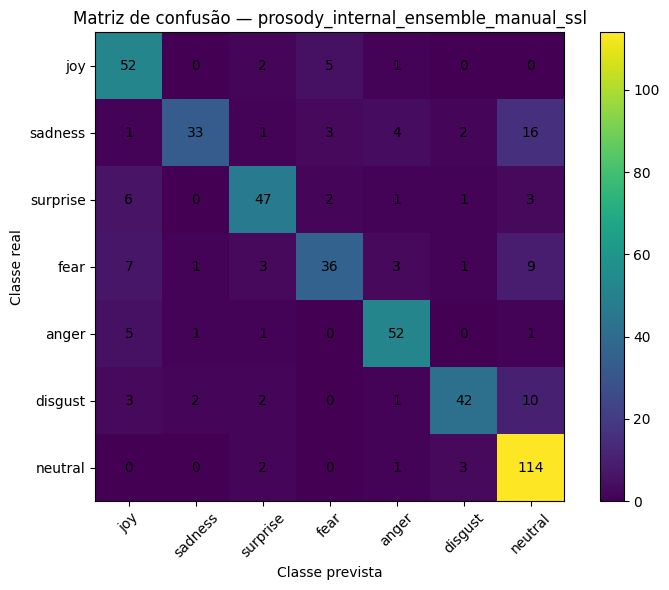

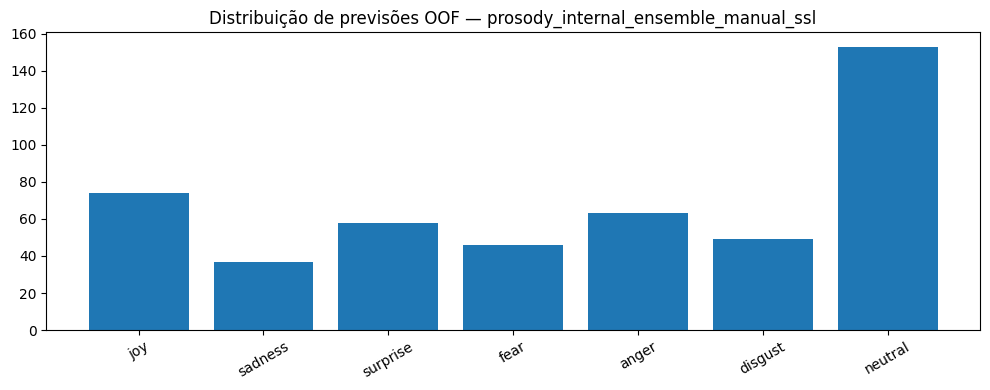

In [14]:
# ============================================================
# 14. Relatórios do melhor modelo/estratégia
# ============================================================

if results_df.empty:
    raise RuntimeError("Nenhum modelo foi avaliado.")

best_row = results_df.iloc[0].to_dict()
best_name = best_row["name"]
print("🏆 Melhor estratégia:", best_name)
print(json.dumps(best_row, indent=2, ensure_ascii=False))

best_probs = oof_prob_store[best_name]
best_preds = np.array([EMOTIONS[i] for i in best_probs.argmax(axis=1)])

print("\n📋 Classification report OOF:")
print(classification_report(y, best_preds, labels=EMOTIONS, zero_division=0))

cm = confusion_matrix(y, best_preds, labels=EMOTIONS)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Matriz de confusão — {best_name}")
plt.colorbar()
plt.xticks(range(len(EMOTIONS)), EMOTIONS, rotation=45)
plt.yticks(range(len(EMOTIONS)), EMOTIONS)
for i in range(len(EMOTIONS)):
    for j in range(len(EMOTIONS)):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.ylabel("Classe real")
plt.xlabel("Classe prevista")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "best_confusion_matrix_v4.png", dpi=160, bbox_inches="tight")
plt.show()

pred_counts = pd.Series(best_preds).value_counts().reindex(EMOTIONS).fillna(0).astype(int)
plt.figure(figsize=(10, 4))
plt.bar(pred_counts.index, pred_counts.values)
plt.title(f"Distribuição de previsões OOF — {best_name}")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "best_prediction_distribution_v4.png", dpi=160, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "true_label": y,
    "predicted_label": best_preds,
    **{f"p_{emo}": best_probs[:, i] for i, emo in enumerate(EMOTIONS)},
}).to_csv(OUTPUT_DIR / "best_oof_predictions_v4.csv", index=False)


In [15]:
# ============================================================
# 15. Treino final nos dados todos e criação do artefacto v4
# ============================================================


def fit_final_model(model_name: str, feature_source: str):
    if feature_source == "manual":
        X_all = X_manual
    elif feature_source == "ssl":
        X_all = X_ssl
    elif feature_source == "combined":
        X_all = X_combined
    else:
        raise ValueError(f"feature_source inválido: {feature_source}")
    builder = builders_store[model_name]
    model = builder(y)
    model.fit(X_all, y)
    return model

models_artifact: Dict[str, Any] = {}
selected_strategy = "single"
selected_model_key = None

# Treina sempre o melhor manual para fallback interpretável.
if best_manual_name:
    manual_model = fit_final_model(best_manual_name, "manual")
    manual_f1 = float(results_df.loc[results_df["name"] == best_manual_name, "f1_macro"].iloc[0])
    models_artifact["manual"] = {
        "name": best_manual_name,
        "pipeline": manual_model,
        "feature_source": "manual",
        "feature_columns": manual_feature_cols,
        "cv_f1_macro": manual_f1,
        "cv_selection_score": float(results_df.loc[results_df["name"] == best_manual_name, "selection_score"].iloc[0]),
    }

# Treina o melhor SSL se existir.
if best_ssl_name:
    ssl_model = fit_final_model(best_ssl_name, "ssl")
    ssl_f1 = float(results_df.loc[results_df["name"] == best_ssl_name, "f1_macro"].iloc[0])
    models_artifact["ssl"] = {
        "name": best_ssl_name,
        "pipeline": ssl_model,
        "feature_source": "ssl",
        "feature_columns": ssl_feature_cols,
        "cv_f1_macro": ssl_f1,
        "cv_selection_score": float(results_df.loc[results_df["name"] == best_ssl_name, "selection_score"].iloc[0]),
    }

# Se o melhor for combined, treina esse modelo também.
if best_row["feature_source"] == "combined":
    combined_model = fit_final_model(best_name, "combined")
    models_artifact["combined"] = {
        "name": best_name,
        "pipeline": combined_model,
        "feature_source": "combined",
        "feature_columns": list(X_combined.columns),
        "manual_feature_columns": manual_feature_cols,
        "ssl_feature_columns": ssl_feature_cols,
        "cv_f1_macro": float(best_row["f1_macro"]),
        "cv_selection_score": float(best_row["selection_score"]),
    }
    selected_strategy = "combined"
    selected_model_key = "combined"
elif best_row["feature_source"] == "ensemble" and "manual" in models_artifact and "ssl" in models_artifact:
    selected_strategy = "ensemble_manual_ssl"
    selected_model_key = "ensemble"
elif best_row["feature_source"] == "ssl" and "ssl" in models_artifact:
    selected_strategy = "single"
    selected_model_key = "ssl"
else:
    selected_strategy = "single"
    selected_model_key = "manual"

# Parâmetros de pós-processamento: reduzem overconfidence e ajudam contra colapso de classe.
postprocess_params = {
    "temperature": 1.20,
    "uniform_mix": 0.06,
    "prior_correction_alpha": 0.12,
    "max_top_probability": 0.78,
}

artifact = {
    "artifact_version": "prosody_v4_advanced_ssl_ensemble",
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "emotions": EMOTIONS,
    "target_sr": TARGET_SR,
    "selected_strategy": selected_strategy,
    "selected_model_key": selected_model_key,
    "best_cv_row": best_row,
    "models": models_artifact,
    "manual_feature_columns": manual_feature_cols,
    "ssl_feature_columns": ssl_feature_cols,
    "ssl_available": bool(ssl_available),
    "ssl_model_name": SSL_MODEL_NAME if ssl_available else None,
    "class_priors": class_priors,
    "postprocess_params": postprocess_params,
    "benchmark_table": results_df.to_dict(orient="records"),
    "notes": (
        "Artefacto v4: ramo clássico + ramo SSL/WavLM quando disponível. "
        "A inferência deve usar as mesmas funções de extração do notebook multimodal v4."
    ),
}

ARTIFACT_PATH = OUTPUT_DIR / "prosody_final_artifact_v4.joblib"
joblib.dump(artifact, ARTIFACT_PATH)

# Compatibilidade: também guarda com nome simples.
joblib.dump(artifact, OUTPUT_DIR / "prosody_final_pipeline_v4.joblib")

print(f"✅ Artefacto final guardado em: {ARTIFACT_PATH.resolve()}")
print("Estratégia selecionada:", selected_strategy)
print("Modelo selecionado:", selected_model_key)
print("Modelos no artefacto:", list(models_artifact.keys()))


✅ Artefacto final guardado em: /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/prosody/prosody_outputs_v4/prosody_final_artifact_v4.joblib
Estratégia selecionada: ensemble_manual_ssl
Modelo selecionado: ensemble
Modelos no artefacto: ['manual', 'ssl']


In [16]:
# ============================================================
# 16. Funções de inferência local para testar o artefacto v4
# ============================================================


def postprocess_distribution(probs: np.ndarray, priors: Dict[str, float], params: Dict[str, float]) -> np.ndarray:
    p = normalize_vector(probs)
    temp = float(params.get("temperature", 1.0))
    if temp > 0 and abs(temp - 1.0) > 1e-6:
        p = np.power(np.clip(p, 1e-12, 1.0), 1.0 / temp)
        p = normalize_vector(p)
    alpha = float(params.get("prior_correction_alpha", 0.0))
    if alpha > 0:
        prior_vec = np.array([max(float(priors.get(e, 1e-9)), 1e-9) for e in EMOTIONS])
        p = p / np.power(prior_vec, alpha)
        p = normalize_vector(p)
    uniform_mix = float(params.get("uniform_mix", 0.0))
    if uniform_mix > 0:
        p = (1.0 - uniform_mix) * p + uniform_mix * (np.ones(len(p)) / len(p))
        p = normalize_vector(p)
    cap = float(params.get("max_top_probability", 1.0))
    if cap < 1.0 and p.max() > cap:
        top = int(np.argmax(p))
        rest = p.copy()
        rest[top] = 0.0
        rest = normalize_vector(rest)
        p = rest * (1.0 - cap)
        p[top] = cap
        p = normalize_vector(p)
    return p


def distribution_from_probs(p: np.ndarray) -> Dict[str, float]:
    p = normalize_vector(p)
    return {emo: round(float(p[i]), 4) for i, emo in enumerate(EMOTIONS)}


def make_feature_frame(values: Dict[str, float] | np.ndarray, columns: List[str]) -> pd.DataFrame:
    if isinstance(values, dict):
        return pd.DataFrame([{c: values.get(c, np.nan) for c in columns}])
    arr = np.asarray(values, dtype=float).reshape(1, -1)
    if arr.shape[1] != len(columns):
        raise ValueError(f"Dimensão inválida: {arr.shape[1]} valores para {len(columns)} colunas.")
    return pd.DataFrame(arr, columns=columns)


def predict_prosody_v4(audio_path: str | Path, artifact_path: Path = ARTIFACT_PATH) -> Dict[str, Any]:
    art = joblib.load(artifact_path)
    emotions = art["emotions"]
    models = art["models"]
    priors = art.get("class_priors", {})
    params = art.get("postprocess_params", {})
    strategy = art.get("selected_strategy", "single")
    selected_key = art.get("selected_model_key", "manual")

    manual_feats = extract_manual_features_from_file(audio_path, audio_id=Path(audio_path).stem)
    manual_X = make_feature_frame(manual_feats, art["manual_feature_columns"])

    branch_probs: Dict[str, np.ndarray] = {}
    branch_dists: Dict[str, Dict[str, float]] = {}

    if "manual" in models:
        p_manual = aligned_predict_proba(models["manual"]["pipeline"], manual_X, emotions)[0]
        branch_probs["manual"] = p_manual
        branch_dists["manual"] = distribution_from_probs(postprocess_distribution(p_manual, priors, params))

    ssl_X = None
    ssl_needed = strategy in {"combined", "ensemble_manual_ssl"} or selected_key == "ssl"
    if art.get("ssl_available") and "ssl" in models and ssl_needed:
        try:
            emb = extract_ssl_embedding_from_file(audio_path, art.get("ssl_model_name") or SSL_MODEL_NAME)
            ssl_X = make_feature_frame(emb, art["ssl_feature_columns"])
            p_ssl = aligned_predict_proba(models["ssl"]["pipeline"], ssl_X, emotions)[0]
            branch_probs["ssl"] = p_ssl
            branch_dists["ssl"] = distribution_from_probs(postprocess_distribution(p_ssl, priors, params))
        except Exception as e:
            print("⚠️ Ramo SSL falhou na inferência; fallback para ramo manual.", repr(e))

    if strategy == "combined" and "combined" in models and ssl_X is not None:
        combined_X = pd.concat([manual_X.reset_index(drop=True), ssl_X.reset_index(drop=True)], axis=1)
        combined_X = combined_X[models["combined"]["feature_columns"]]
        p = aligned_predict_proba(models["combined"]["pipeline"], combined_X, emotions)[0]
        internal_weights = {"combined": 1.0}
    elif strategy == "ensemble_manual_ssl" and "manual" in branch_probs and "ssl" in branch_probs:
        rel_manual = float(models["manual"].get("cv_f1_macro", 0.35))
        rel_ssl = float(models["ssl"].get("cv_f1_macro", 0.35))
        p_stack, metas = adaptive_two_branch_ensemble_probs(
            branch_probs["manual"].reshape(1, -1),
            branch_probs["ssl"].reshape(1, -1),
            rel_manual,
            rel_ssl,
        )
        p = p_stack[0]
        internal_weights = {"manual": metas[0]["w_a"], "ssl": metas[0]["w_b"]}
    else:
        key = selected_key if selected_key in branch_probs else "manual"
        p = branch_probs[key]
        internal_weights = {key: 1.0}

    p_post = postprocess_distribution(p, priors, params)
    dist = distribution_from_probs(p_post)
    ranking = sorted(dist.items(), key=lambda kv: kv[1], reverse=True)
    return {
        "audio_path": str(audio_path),
        "distribution": dist,
        "dominant_emotion": ranking[0][0],
        "dominant_confidence": ranking[0][1],
        "ranking": ranking,
        "selected_strategy": strategy,
        "internal_weights": {k: round(float(v), 4) for k, v in internal_weights.items()},
        "branch_distributions": branch_dists,
    }

print("✅ Função predict_prosody_v4 pronta.")


✅ Função predict_prosody_v4 pronta.


In [19]:
# ============================================================
# 17. Teste rápido opcional em áudios locais
# ============================================================
# Coloca ficheiros .wav/.mp3 em ./audios_teste/ para testar.

TEST_AUDIO_DIR = Path("audios_teste2")
if TEST_AUDIO_DIR.exists():
    test_files = [p for p in sorted(TEST_AUDIO_DIR.rglob("*")) if p.suffix.lower() in AUDIO_EXTS]
else:
    test_files = []

if not test_files:
    print("ℹ️ Sem áudios de teste em ./audios_teste/. Célula opcional concluída.")
else:
    test_rows = []
    for p in test_files:
        try:
            res = predict_prosody_v4(p)
            print("\n", "=" * 80)
            print("🎙️", p.name)
            print("Prosódia:", res["dominant_emotion"], res["dominant_confidence"])
            print("Distribuição:", res["distribution"])
            print("Pesos internos:", res["internal_weights"])
            test_rows.append({
                "file": p.name,
                "dominant": res["dominant_emotion"],
                "confidence": res["dominant_confidence"],
                **{f"p_{e}": res["distribution"][e] for e in EMOTIONS},
            })
        except Exception as e:
            print(f"⚠️ Erro em {p.name}: {repr(e)}")
    if test_rows:
        test_df = pd.DataFrame(test_rows)
        test_df.to_csv(OUTPUT_DIR / "prosody_test_audio_predictions_v4.csv", index=False)
        display(test_df)



🎙️ anger.wav
Prosódia: joy 0.4357
Distribuição: {'joy': 0.4357, 'sadness': 0.0268, 'surprise': 0.0692, 'fear': 0.1071, 'anger': 0.2832, 'disgust': 0.0515, 'neutral': 0.0265}
Pesos internos: {'manual': 0.2954, 'ssl': 0.7046}

🎙️ disgust.wav
Prosódia: joy 0.5023
Distribuição: {'joy': 0.5023, 'sadness': 0.026, 'surprise': 0.0612, 'fear': 0.1007, 'anger': 0.163, 'disgust': 0.1213, 'neutral': 0.0255}
Pesos internos: {'manual': 0.2786, 'ssl': 0.7214}

🎙️ fear.wav
Prosódia: joy 0.6391
Distribuição: {'joy': 0.6391, 'sadness': 0.0259, 'surprise': 0.0546, 'fear': 0.0946, 'anger': 0.1092, 'disgust': 0.0416, 'neutral': 0.0351}
Pesos internos: {'manual': 0.2479, 'ssl': 0.7521}

🎙️ joy.wav
Prosódia: joy 0.6505
Distribuição: {'joy': 0.6505, 'sadness': 0.0244, 'surprise': 0.054, 'fear': 0.0924, 'anger': 0.1131, 'disgust': 0.0409, 'neutral': 0.0246}
Pesos internos: {'manual': 0.2462, 'ssl': 0.7538}

🎙️ neutral.wav
Prosódia: joy 0.5707
Distribuição: {'joy': 0.5707, 'sadness': 0.0252, 'surprise': 0.1146

,file,dominant,confidence,p_joy,p_sadness,p_surprise,p_fear,p_anger,p_disgust,p_neutral
0,anger.wav,joy,0.4357,0.4357,0.0268,0.0692,0.1071,0.2832,0.0515,0.0265
1,disgust.wav,joy,0.5023,0.5023,0.0260,0.0612,0.1007,0.1630,0.1213,0.0255
2,fear.wav,joy,0.6391,0.6391,0.0259,0.0546,0.0946,0.1092,0.0416,0.0351
3,joy.wav,joy,0.6505,0.6505,0.0244,0.0540,0.0924,0.1131,0.0409,0.0246
4,neutral.wav,joy,0.5707,0.5707,0.0252,0.1146,0.1003,0.1132,0.0452,0.0307
5,sad.wav,neutral,0.3607,0.2036,0.0415,0.0696,0.1095,0.1724,0.0426,0.3607
6,surprise.wav,joy,0.5252,0.5252,0.0251,0.0618,0.1044,0.2120,0.0459,0.0255


## Como defender esta versão no relatório

A versão v4 do módulo de prosódia deve ser apresentada como uma evolução do baseline clássico:

- o **SVM RBF com features acústicas manuais** continua a existir como baseline interpretável;
- o ramo **WavLM/wav2vec2** usa transferência de aprendizagem, extraindo embeddings acústicos de um modelo pré-treinado em larga escala;
- como o dataset de prosódia é pequeno, o modelo pré-treinado fica **congelado** e só é treinado um classificador leve por cima;
- a seleção final usa F1-macro em validação por locutor, penalizando modelos que colapsam numa classe;
- a saída continua a ser uma distribuição probabilística pelas 7 emoções, adequada à fusão multimodal.

Formulação curta:

> Para tornar o módulo acústico mais robusto, foi implementada uma arquitetura híbrida de prosódia, combinando características acústicas manuais com representações extraídas de modelos auto-supervisionados de fala. Esta decisão permite beneficiar de conhecimento pré-treinado sem exigir fine-tuning completo, o que seria inadequado dada a dimensão reduzida do dataset.